In [1]:
import pandas as pd
import xgboost as xgb
import sys
sys.path.append('../')
sys.path.append('./')

from utils.helper_functions import ( 
    read_csv_incl_timeindex, 
    get_color, 
    rel_symmetric_difference, 
    plot_dependency,
)
from utils.feature_configuration import (
    additional_nuc_avail, 
    edges_FR_price, 
    edges_FR_export,
    edges_ES_price,
    paper_rename_dict_including_units
)
import dill
import os

In [2]:
import matplotlib
matplotlib.rcParams['pgf.texsystem'] = 'pdflatex'
matplotlib.rcParams.update({'font.family': 'serif', 'font.size': 16,
    'axes.labelsize': 16,'axes.titlesize': 16, 'figure.titlesize' : 18})
matplotlib.rcParams['text.usetex'] = True
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Set global font sizes
plt.rcParams['axes.titlesize'] = 16       # For axes titles
plt.rcParams['axes.labelsize'] = 16       # For x and y labels
plt.rcParams['legend.fontsize'] = 16      # For legend text
plt.rcParams['figure.titlesize'] = 18     # For suptitle (figure title)
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16

In [3]:
figure_folder = "../figs_for_paper/"
if os.path.exists(figure_folder):
    print(f"Figure folder '{figure_folder}' already exists.")
else:
    os.makedirs(figure_folder)
    print(f"Figure folder '{figure_folder}' created.")

Figure folder '../figs_for_paper/' already exists.


In [4]:
# Load entire dataset in order to replace the features with hypethetical values in the what-if analysis
file_path = '../data/data_selected_2018-2023.csv'
dataset_all_features = pd.read_csv(file_path)
dataset_all_features.index = pd.to_datetime(dataset_all_features['timestamp'])

In [5]:
periods = [('2018-01-01', '2023-12-31')]

model_dict_gas_cap = {}
countries = ['ES', 'FR']
for country in countries:
    model_dict_gas_cap[country] = {}
    if country == 'FR':
        targets = ['FR_price']
    elif country == 'ES':
        targets = ['ES_price']
    for target in targets:
        for start_date, end_date in periods:
                model_name = 'xgb_{}_start_{}_end_{}'.format(target, start_date, end_date)

                X_test = read_csv_incl_timeindex('../data/X_test_features_target_xgb_{}_start_{}_end_{}.csv'.format(target, start_date, end_date))
                X_train = read_csv_incl_timeindex('../data/X_train_features_target_xgb_{}_start_{}_end_{}.csv'.format(target, start_date, end_date))
                X_full = read_csv_incl_timeindex('../data/X_full_features_target_xgb_{}_start_{}_end_{}.csv'.format(target, start_date, end_date))

                y_test = read_csv_incl_timeindex('../data/y_test_xgb_{}_start_{}_end_{}.csv'.format(target, start_date, end_date))
                y_train = read_csv_incl_timeindex('../data/y_train_xgb_{}_start_{}_end_{}.csv'.format(target, start_date, end_date))
                y_full = read_csv_incl_timeindex('../data/y_full_xgb_{}_start_{}_end_{}.csv'.format(target, start_date, end_date))

                X_crisis = X_full
                y_crisis = y_full
                # choose only samples from the interval of the Spanish gas price cap (dates according to https://www.jstor.org/stable/resrep70918?seq=1)
                X_crisis = X_crisis.loc[(X_crisis.index >= pd.to_datetime('2022-06-15 00:00:00', utc=True)) & (X_crisis.index < pd.to_datetime('2023-02-27 00:00:00', utc=True))]
                y_crisis = y_crisis.loc[X_crisis.index]

                model =  xgb.XGBRegressor()
                model.load_model("../models/{}_best.json".format(model_name))

                model_dict_gas_cap[country][target] = (model, X_test, y_test, X_crisis, y_crisis, X_full, y_full)
                print('Model Score (R^2):', model.score(X_test, y_test))

Model Score (R^2): 0.9503921270370483
Model Score (R^2): 0.9554727077484131


# Data selection for France and Spain

In [6]:
# Load model and data from the dictionary for the what-if analysis on the Spanish gas price cap, which is a hypothetical scenario that we want to evaluate in the what-if analysis
model_ES_crisis = model_dict_gas_cap['ES']['ES_price'][0]
X_ES_test = model_dict_gas_cap['ES']['ES_price'][1]
X_ES_crisis = model_dict_gas_cap['ES']['ES_price'][3]
X_ES_crisis_no_cap = X_ES_crisis.copy()
X_ES_crisis_no_cap['gas_price_ES'] = dataset_all_features.loc[X_ES_crisis_no_cap.index, 'gas_price_MIBGAS']
y_ES_crisis = model_dict_gas_cap['ES']['ES_price'][4]
y_pred_ES_crisis = pd.Series(model_ES_crisis.predict(X_ES_crisis), index=X_ES_crisis.index)
y_pred_ES_crisis_no_cap = pd.Series(model_ES_crisis.predict(X_ES_crisis_no_cap), index=X_ES_crisis_no_cap.index)

# What if analysis for nuclear availibility

In [7]:
periods = [('2018-01-01', '2023-12-31')]

model_dict_nuc_avail = {}
countries = ['FR']
for country in countries:
    model_dict_nuc_avail[country] = {}
    if country == 'FR':
        targets = ['FR_price']
    elif country == 'ES':
        targets = ['ES_price']
    for target in targets:
        for start_date, end_date in periods:
                model_name = 'xgb_{}_start_{}_end_{}'.format(target, start_date, end_date)

                X_test = read_csv_incl_timeindex('../data/X_test_features_target_xgb_{}_start_{}_end_{}.csv'.format(target, start_date, end_date))
                X_train = read_csv_incl_timeindex('../data/X_train_features_target_xgb_{}_start_{}_end_{}.csv'.format(target, start_date, end_date))
                X_full = read_csv_incl_timeindex('../data/X_full_features_target_xgb_{}_start_{}_end_{}.csv'.format(target, start_date, end_date))

                y_test = read_csv_incl_timeindex('../data/y_test_xgb_{}_start_{}_end_{}.csv'.format(target, start_date, end_date))
                y_train = read_csv_incl_timeindex('../data/y_train_xgb_{}_start_{}_end_{}.csv'.format(target, start_date, end_date))
                y_full = read_csv_incl_timeindex('../data/y_full_xgb_{}_start_{}_end_{}.csv'.format(target, start_date, end_date))

                X_nuc_avail_crisis = X_full
                y_nuc_avail_crisis = y_full
                X_nuc_avail_crisis = X_nuc_avail_crisis.loc[(X_nuc_avail_crisis.index >= pd.to_datetime('2022-01-01 00:00:00', utc=True)) & (X_nuc_avail_crisis.index < pd.to_datetime('2023-01-01 00:00:00', utc=True))]
                y_nuc_avail_crisis = y_nuc_avail_crisis.loc[X_nuc_avail_crisis.index]

                model =  xgb.XGBRegressor()
                model.load_model("../models/{}_best.json".format(model_name))
                seed = 7

                model_dict_nuc_avail[country][target] = (model, X_test, y_test, X_nuc_avail_crisis, y_nuc_avail_crisis, X_full, y_full)
                print('Model Score (R^2):', model.score(X_test, y_test))

Model Score (R^2): 0.9554727077484131


In [8]:
# Load model and data from the dictionary for the what-if analysis on nuclear availability, which is a hypothetical scenario that we want to evaluate in the what-if analysis
model_FR_nuc_avail_crisis = model_dict_nuc_avail['FR']['FR_price'][0]
X_FR_test = model_dict_nuc_avail['FR']['FR_price'][1]
X_FR_nuc_avail_crisis = model_dict_nuc_avail['FR']['FR_price'][3]
y_FR_nuc_avail_crisis = model_dict_nuc_avail['FR']['FR_price'][4]
X_FR_nuc_avail_crisis_higher_availability = X_FR_nuc_avail_crisis.copy()

# +  hypothetical additional_nuc_avail MW nuclear availability, which is a hypothetical scenario that we want to evaluate in the what-if analysis
X_FR_nuc_avail_crisis_higher_availability['nuclear_avail_rte_FR'] += additional_nuc_avail 
y_pred_FR_nuc_avail_crisis = pd.Series(model_FR_nuc_avail_crisis.predict(X_FR_nuc_avail_crisis), index=X_FR_nuc_avail_crisis.index)
y_pred_FR_nuc_avail_crisis_higher_availability = pd.Series(model_FR_nuc_avail_crisis.predict(X_FR_nuc_avail_crisis_higher_availability), index=X_FR_nuc_avail_crisis_higher_availability.index)

# Plot figure of both what-if scenarios (Figure 7)

C:\Users\bt8891\AppData\Local\Temp\ipykernel_26896\3530817562.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_c.set_xticklabels(ax_c.get_xticklabels(), rotation=45)
C:\Users\bt8891\AppData\Local\Temp\ipykernel_26896\3530817562.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_d.set_xticklabels(ax_d.get_xticklabels(), rotation=45)


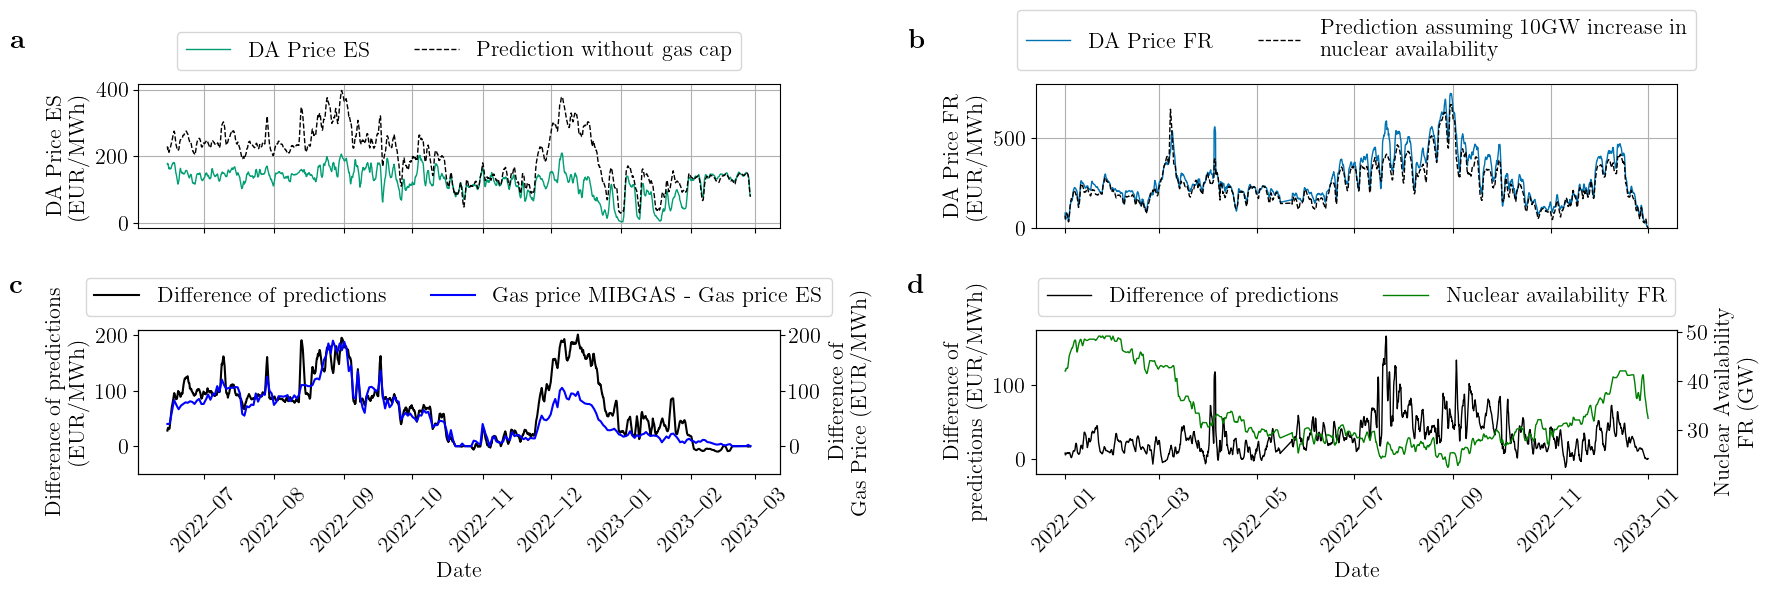

In [9]:
fig = plt.figure(figsize=(18,6))
gs = GridSpec(2, 2, figure=fig)


ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, 0])
ax_d = fig.add_subplot(gs[1, 1])

ax_a.plot(y_ES_crisis.rolling('D').mean(), label = 'DA Price ES', color = get_color('ES_price'), alpha = 1, linewidth=1)
ax_a.plot(y_pred_ES_crisis_no_cap.rolling('D').mean(), label = "Prediction without gas cap", color = 'black', 
          alpha = 1, linewidth=1, linestyle='dashed')
ax_a.set_ylabel('DA Price ES \n(EUR/MWh)')
ax_a.set_xticklabels([])
ax_a.grid(True)
ax_a.legend(ncol = 2, bbox_to_anchor=(0.5, 1.02), loc='lower center')

l1 = ax_c.plot((y_pred_ES_crisis_no_cap- y_pred_ES_crisis).rolling('D').mean(), label = "Difference of predictions", color = 'black')
ax_c2 = ax_c.twinx()
l2 = ax_c2.plot(((dataset_all_features['gas_price_MIBGAS'] - dataset_all_features['gas_price_ES']).loc[y_pred_ES_crisis_no_cap.index[0]:y_pred_ES_crisis_no_cap.index[-1]]).rolling('D').mean(), 
           label = "Gas price MIBGAS - Gas price ES", color = 'blue')

ax_c.set_xlabel('Date')
ax_c.set_ylabel('Difference of predictions \n(EUR/MWh)')
ax_c2.set_ylabel('Difference of \nGas Price (EUR/MWh)')
ax_c.set_xticklabels(ax_c.get_xticklabels(), rotation=45)
lines = [l1[0], l2[0]]
labels = [line.get_label() for line in lines]
ax_c.legend(lines, labels, ncol = 2, bbox_to_anchor=(0.5, 1.02), loc='lower center')
ax_c.set_ylim(-50, 210)
ax_c2.set_ylim(-50, 210)

ax_b.plot(y_FR_nuc_avail_crisis['price_da_FR'].rolling('D').mean(), label = 'DA Price FR', color = get_color('FR_price'), alpha = 1, linewidth=1)
ax_b.plot(y_pred_FR_nuc_avail_crisis_higher_availability.rolling('D').mean(), label = "Prediction assuming 10GW increase in \nnuclear availability", 
          color = 'black', alpha = 1, linewidth=1, linestyle='dashed')

ax_b.set_ylim(0, 1000)
ax_b.set_xticklabels([])
ax_b.grid(True)
ax_b.set_ylabel('DA Price FR \n(EUR/MWh)')
ax_b.legend(ncol = 2, bbox_to_anchor=(0.5, 1.02), loc='lower center')
ax_b.set_ylim(000,800)

l1 = ax_d.plot((y_pred_FR_nuc_avail_crisis - y_pred_FR_nuc_avail_crisis_higher_availability).rolling('D').mean(),
          label = "Difference of predictions", color = 'black', linewidth=1)
ax_d2 = ax_d.twinx()
l2 = ax_d2.plot((((X_FR_nuc_avail_crisis['nuclear_avail_rte_FR']/1000))).loc['2022-01-01':'2023-01-01'].rolling('D').mean(), 
           label = "Nuclear availability FR", color = 'green', alpha = 1, linewidth=1)

res = (((X_FR_nuc_avail_crisis['nuclear_avail_rte_FR']/1000))).loc['2022-01-01':'2023-01-01'].rolling('D').mean()

lines = [l1[0], l2[0]]
labels = [line.get_label() for line in lines]
ax_d.set_xlabel('Date')
ax_d.set_ylabel('Difference of \npredictions (EUR/MWh)')
ax_d2.set_ylabel('Nuclear Availability \nFR (GW)')
ax_d.set_xticklabels(ax_d.get_xticklabels(), rotation=45)
ax_d.legend(lines, labels, ncol = 2, bbox_to_anchor=(0.5, 1.02), loc='lower center')

panel_label_ls = [r"\textbf{a}", r"\textbf{b}", r"\textbf{c}", 
                  r"\textbf{d}", r"\textbf{e}", r"\textbf{f}", 
                  r"\textbf{g}", r"\textbf{h}", r"\textbf{i}", 
                  r"\textbf{j}", r"\textbf{k}", r"\textbf{l}"]
shift = -.2
for idx_r, ax_r in enumerate([ax_a, ax_b, ax_c, ax_d]):
    ax_r.text(0 + shift, 1.3, panel_label_ls[idx_r],
                weight='bold', verticalalignment='center', 
                transform=ax_r.transAxes, fontsize = 20)

fig.align_ylabels()

fig.subplots_adjust(hspace=0.7, wspace=0.4, bottom=0.2, left=0.075, right=0.93, top=0.85)
fig.savefig(figure_folder + 'what_if_scenario_gas_cap_and_nuclear_availability.pdf')

In [10]:
'''Metrics for the what-if scenarios'''

print('Gas price cap scenario: \n')
print('Length of the dataset under consideration:', len(y_ES_crisis))
print('Average DA price:', y_ES_crisis['price_da_ES'].mean())
print('Average predicted DA price:', y_pred_ES_crisis_no_cap.mean())
print('Relative difference:', ((y_pred_ES_crisis_no_cap.mean() - y_ES_crisis['price_da_ES'].mean())/(y_pred_ES_crisis_no_cap.mean())))
print('Relative symmetric difference:', rel_symmetric_difference(y_ES_crisis['price_da_ES'], y_pred_ES_crisis_no_cap).mean())
print('Mean difference:', ((y_pred_ES_crisis_no_cap-y_ES_crisis['price_da_ES'])).mean())
print('Max difference:', ((y_pred_ES_crisis_no_cap-y_ES_crisis['price_da_ES'])).max())
print('Max difference (rolling daily mean):', ((y_pred_ES_crisis_no_cap-y_ES_crisis['price_da_ES']).rolling('D').mean()).max())

print('\n \nNuclear availability scenario: \n')
print('Length of the dataset under consideration:', len(y_FR_nuc_avail_crisis))
print('Average DA price:', y_FR_nuc_avail_crisis['price_da_FR'].mean())
print('Average predicted DA price (higher availability):', y_pred_FR_nuc_avail_crisis_higher_availability.mean())
print('Relative difference:', ((y_FR_nuc_avail_crisis['price_da_FR'].mean() - y_pred_FR_nuc_avail_crisis_higher_availability.mean())/(y_FR_nuc_avail_crisis['price_da_FR'].mean())))
print('Relative symmetric difference:', rel_symmetric_difference(y_FR_nuc_avail_crisis['price_da_FR'], y_pred_FR_nuc_avail_crisis_higher_availability).mean())
print('Mean difference:', ((y_FR_nuc_avail_crisis['price_da_FR'] - y_pred_FR_nuc_avail_crisis_higher_availability)).mean())
print('Max difference:', ((y_FR_nuc_avail_crisis['price_da_FR'] - y_pred_FR_nuc_avail_crisis_higher_availability)).max())
print('Max difference (rolling daily mean):', ((y_FR_nuc_avail_crisis['price_da_FR'] - y_pred_FR_nuc_avail_crisis_higher_availability).rolling('D').mean()).max())
print('Max difference between July and September 2022:', ((y_FR_nuc_avail_crisis['price_da_FR'] - y_pred_FR_nuc_avail_crisis_higher_availability)).loc['2022-07-01':'2022-09-30'].max())
print('Max difference (rolling daily mean) between July and September 2022:', ((y_FR_nuc_avail_crisis['price_da_FR'] - y_pred_FR_nuc_avail_crisis_higher_availability).rolling('D').mean()).loc['2022-07-01':'2022-09-30'].max())

Gas price cap scenario: 

Length of the dataset under consideration: 6165
Average DA price: 123.92608596918087
Average predicted DA price: 195.62384
Relative difference: 0.36650826525620894
Relative symmetric difference: 0.48657992714273784
Mean difference: 71.69774881788781
Max difference: 241.0033447265625
Max difference (rolling daily mean): 196.95428904215495

 
Nuclear availability scenario: 

Length of the dataset under consideration: 8491
Average DA price: 278.2773030267342
Average predicted DA price (higher availability): 247.09769
Relative difference: 0.11204512879787631
Relative symmetric difference: 0.15583354091194435
Mean difference: 31.179616705053704
Max difference: 1846.8674023437502
Max difference (rolling daily mean): 183.61847656249998
Max difference between July and September 2022: 359.25116455078125
Max difference (rolling daily mean) between July and September 2022: 183.61847656249998


# Shapley Flow values for what-if scenarios (Supplementary Figure 10)

In [11]:
creditflow_dict = {}
model_dict = {}
fg_dict = {}
bg_dict = {}

creditflow_dict_what_if = {}
fg_dict_what_if = {}
bg_dict_what_if = {}

graph_dict = {}
target_names = []
periods = [('2018-01-01', '2023-12-31')]

countries = ['FR', 'ES']
for country in countries:
    if country == 'FR':
        targets = ['FR_price']
        other_country = 'ES'
    elif country == 'ES':
        targets = ['ES_price']
        other_country = 'FR'
        edges = edges_ES_price
    for target in targets:
        target_names.append(target)
        if (country == 'FR') and (target == 'FR_price'):
            edges = edges_FR_price
        elif (country == 'FR') and (target == 'FR_export'):
            edges = edges_FR_export
        for start_date, end_date in periods:
            model_name = 'xgb_{}_start_{}_end_{}_best'.format(target, start_date, end_date)
            cf_file_name = 'flow_xgb_{}_start_{}_end_{}'.format(target, start_date, end_date)
            with open('../credit_flow/{}.pkl'.format(cf_file_name), 'rb') as file:
                loaded_cf = dill.load(file)
            with open('../credit_flow/what_if_scenarios/{}.pkl'.format(cf_file_name), 'rb') as file:
                loaded_cf_what_if = dill.load(file)
                creditflow_dict[target] = loaded_cf
                creditflow_dict_what_if[target] = loaded_cf_what_if
            model = xgb.Booster()
            
            model.load_model("../models/{}.json".format(model_name))
            model_dict[target] = model

            fg_dict[target] = read_csv_incl_timeindex('../credit_flow/fg_xgb_{}_start_{}_end_{}.csv'.format(target, start_date, end_date))
            bg_dict[target] = read_csv_incl_timeindex('../credit_flow/bg_xgb_{}_start_{}_end_{}.csv'.format(target, start_date, end_date))
            fg_dict_what_if[target] = read_csv_incl_timeindex('../credit_flow/what_if_scenarios/fg_xgb_{}_start_{}_end_{}.csv'.format(target, start_date, end_date))
            bg_dict_what_if[target] = read_csv_incl_timeindex('../credit_flow/what_if_scenarios/bg_xgb_{}_start_{}_end_{}.csv'.format(target, start_date, end_date))

            # saving graphs if you want to plot the graphs
            graph_name = 'xgb_{}_start_{}_end_{}'.format(target, start_date, end_date)
            with open('../credit_flow/causal_graph_{}.pkl'.format(graph_name), 'rb') as file:
                causal_graph = dill.load(file)
                graph_dict[target] = causal_graph
            with open('../credit_flow/what_if_scenarios/causal_graph_{}.pkl'.format(graph_name), 'rb') as file:
                causal_graph_what_if = dill.load(file)

# Plot figure for Shapley Flow values of what-if scenarios (Suppl. Figure 10)

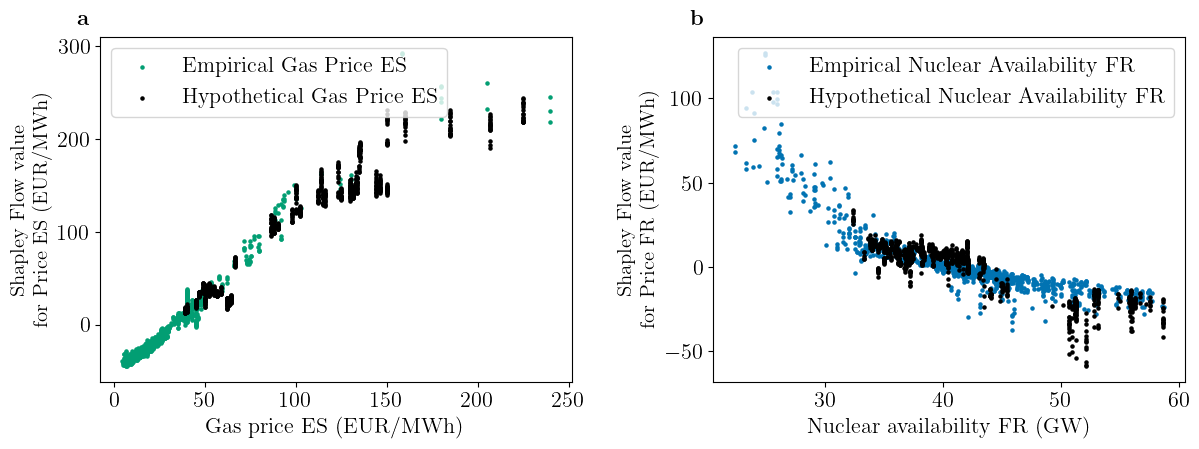

In [ ]:
fig,ax = plt.subplots(1, 2, figsize=(14, 3))
scale_color = 1

for i, (target, node1_name) in enumerate(zip(['ES_price', 'FR_price'], ['gas_price_ES', 'nuclear_avail_rte_FR'])):

    scale_y = 1
    cf = creditflow_dict[target]
    fg_values = fg_dict[target]
    cf_what_if = creditflow_dict_what_if[target]
    fg_values_what_if = fg_dict_what_if[target]
    target_node = target
    if paper_rename_dict_including_units[node1_name][-4:] == '(GW)':
        scale_x = 1000
    else:
        scale_x = 1
    if target == 'ES_price':
        label_emp = 'Empirical Gas Price ES'
        label_what_if = 'Hypothetical Gas Price ES'
    if target == 'FR_price':
        label_emp = 'Empirical Nuclear Availability FR'
        label_what_if = 'Hypothetical Nuclear Availability FR'
        
    # plot the Shapley Flow values for the empirical scenario and the hypothetical scenario in the what-if analysis
    shapley_flow_values = plot_dependency(node1_name, target_node, cf, fg_values, color=get_color(target), 
                    x_label='',
                    color_label = None, scale_color=scale_color, scale_x=scale_x, 
                    scale_y=scale_y, axes=ax[i], fig =fig,
                    label = label_emp)
    shapley_flow_values_what_if = plot_dependency(node1_name, target_node, cf_what_if, fg_values_what_if, color='black', 
                    x_label='',
                    color_label=None, scale_color=scale_color, scale_x=scale_x, 
                    scale_y=scale_y, axes=ax[i], fig = fig,
                    label = label_what_if)
panel_label_ls = [r"\textbf{a}", r"\textbf{b}", r"\textbf{c}", 
                  r"\textbf{d}", r"\textbf{e}", r"\textbf{f}", 
                  r"\textbf{g}", r"\textbf{h}", r"\textbf{i}", 
                  r"\textbf{j}", r"\textbf{k}", r"\textbf{l}"]
shift = -.05
for idx_r, ax_r in enumerate(ax.flatten()):
    ax_r.text(0 + shift, 1.05, panel_label_ls[idx_r],
                weight='bold', verticalalignment='center',
                transform=ax_r.transAxes)
ax[0].set_ylabel('Shapley Flow value \nfor Price ES (EUR/MWh)', fontsize=15)
ax[1].set_ylabel('Shapley Flow value \nfor Price FR (EUR/MWh)', fontsize=15)
ax[0].legend(loc='upper left')
ax[1].legend(loc='upper right')
fig.subplots_adjust(wspace=0.3, hspace=0.5, top=1.2, bottom=0.05)
fig.savefig(figure_folder + 'shapley_flow_what_if_scenario_comparison.pdf', bbox_inches='tight')